# Задание 1.

Поработаем с датасетом Black Friday. Есть его описание:

Description

The dataset here is a sample of the transactions made in a retail store. The store wants to know better the customer purchase behaviour against different products. Specifically, here the problem is a regression problem where we are trying to predict the dependent variable (the amount of purchase) with the help of the information contained in the other variables.

Classification problem can also be settled in this dataset since several variables are categorical, and some other approaches could be "Predicting the age of the consumer" or even "Predict the category of goods bought". This dataset is also particularly convenient for clustering and maybe find different clusters of consumers within it.

In [251]:
import pandas as pd
import numpy as np
from matplotlib import pylab as plt

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [252]:
data = pd.read_csv('BlackFriday.csv')
data.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


# Подготовка данных

In [253]:
missing_values = data.isnull().sum().sort_values(ascending = False)
missing_values = missing_values[missing_values > 0]/data.shape[0]
print(f'{missing_values *100} %')

Product_Category_3    69.441029
Product_Category_2    31.062713
dtype: float64 %


Скорее всего NaN-ы в Product_Category_2 и Product_Category_3 означают, что человек не покупал продукты из этих категорий.

Поэтому можем заменить эти пропущенные значения на 0.

In [254]:
data = data.fillna(0)

In [255]:
data.shape

(537577, 12)

In [256]:
missing_values = data.isnull().sum().sort_values(ascending = False)
missing_values = missing_values[missing_values > 0] / data.shape[0]
print(f'{missing_values * 100} %')

Series([], dtype: float64) %


Посмотрим, какие типы данных есть в нашем датасете. 

Выведите на экран тип каждой колонки в таблице.

In [257]:
data.dtypes

User_ID                         int64
Product_ID                     object
Gender                         object
Age                            object
Occupation                      int64
City_Category                  object
Stay_In_Current_City_Years     object
Marital_Status                  int64
Product_Category_1              int64
Product_Category_2            float64
Product_Category_3            float64
Purchase                        int64
dtype: object

Обработаем нечисловые колонки.

1) Выведите на экран все возможные значения из столбца Gender.

2) Замените значение 'M' на 1, а 'F' на 0.

In [258]:
data['Gender'] = data['Gender'].apply(lambda x: 1 if x == 'M' else 0)
data['Gender']

0         0
1         0
2         0
3         0
4         1
         ..
537572    1
537573    1
537574    1
537575    1
537576    1
Name: Gender, Length: 537577, dtype: int64

Поработаем со столбцом Age.

1) Выведите на экран все возможные значения из столбца Age.

2) Напишите функцию для перевода каждого диапазона возрастов в число (самые маленькие возрасты - 0, следующий диапазон - 1 и т.д.). Замените значения в столбце Age на числовые, применив эту функцию.

In [259]:
data['Age'].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [260]:
data[data['Age'].isna()]

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase


In [261]:
#your code here

def map_age(age):
    #print(age)
    if age == '0-17':
        return 1
    elif age == '18-25':
        return 2
    elif age == '26-35':
        return 3
    elif age == '36-45':
        return 4
    elif age == '46-50':
        return 5
    elif age == '55+':
        return 6
    
data['Age'] = data['Age'].map(map_age)
data[14:19]

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
14,1000006,P00231342,0,NaN,9,A,1,0,5,8.0,14.0,5378
15,1000006,P00190242,0,NaN,9,A,1,0,4,5.0,0.0,2079
16,1000006,P0096642,0,NaN,9,A,1,0,2,3.0,4.0,13055
17,1000006,P00058442,0,NaN,9,A,1,0,5,14.0,0.0,8851
18,1000007,P00036842,1,4.0,1,B,1,1,1,14.0,16.0,11788


In [262]:
data = data.dropna()
data

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,0,1.0,10,A,2,0,3,0.0,0.0,8370
1,1000001,P00248942,0,1.0,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,0,1.0,10,A,2,0,12,0.0,0.0,1422
3,1000001,P00085442,0,1.0,10,A,2,0,12,14.0,0.0,1057
4,1000002,P00285442,1,6.0,16,C,4+,0,8,0.0,0.0,7969
...,...,...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,1,4.0,16,C,1,0,1,2.0,0.0,11664
537573,1004737,P00111142,1,4.0,16,C,1,0,1,15.0,16.0,19196
537574,1004737,P00345942,1,4.0,16,C,1,0,8,15.0,0.0,8043
537575,1004737,P00285842,1,4.0,16,C,1,0,5,0.0,0.0,7172


Обработаем столбец City_Category.

1) Выведите все уникальные значения данного столбца.

2) Закодируйте столбец с помощью OneHotEncoding (get_dummies).

In [263]:
data['City_Category'].unique()
data = pd.get_dummies(data=data, columns=['City_Category'], drop_first=True)

In [264]:
data

,User_ID,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,City_Category_B,City_Category_C
0,1000001,P00069042,0,1.0,10,2,0,3,0.0,0.0,8370,False,False
1,1000001,P00248942,0,1.0,10,2,0,1,6.0,14.0,15200,False,False
2,1000001,P00087842,0,1.0,10,2,0,12,0.0,0.0,1422,False,False
3,1000001,P00085442,0,1.0,10,2,0,12,14.0,0.0,1057,False,False
4,1000002,P00285442,1,6.0,16,4+,0,8,0.0,0.0,7969,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,1,4.0,16,1,0,1,2.0,0.0,11664,False,True
537573,1004737,P00111142,1,4.0,16,1,0,1,15.0,16.0,19196,False,True
537574,1004737,P00345942,1,4.0,16,1,0,8,15.0,0.0,8043,False,True
537575,1004737,P00285842,1,4.0,16,1,0,5,0.0,0.0,7172,False,True


Наконец, обработаем Stay_In_Current_City_Years.

1) Выведите на экран все уникальные значения данного столбца.

2) Замените '4+' на 4, а все остальные значения оставьте как есть, но переведите их в числовой вид (x -> int(x)).

In [265]:
#your code here

def map_stay(years):
    if years == '4+':
        return 4
    else:
        return int(years)
    
data['Stay_In_Current_City_Years'] = data['Stay_In_Current_City_Years'].apply(map_stay)

In [266]:
data.head()

,User_ID,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,City_Category_B,City_Category_C
0,1000001,P00069042,0,1.0,10,2,0,3,0.0,0.0,8370,False,False
1,1000001,P00248942,0,1.0,10,2,0,1,6.0,14.0,15200,False,False
2,1000001,P00087842,0,1.0,10,2,0,12,0.0,0.0,1422,False,False
3,1000001,P00085442,0,1.0,10,2,0,12,14.0,0.0,1057,False,False
4,1000002,P00285442,1,6.0,16,4,0,8,0.0,0.0,7969,False,True


Удалим столбцы User_ID и Product_ID.

In [267]:
data.drop(columns=['User_ID', 'Product_ID'], axis=1, inplace=True)

In [268]:
data.head()

,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,City_Category_B,City_Category_C
0,0,1.0,10,2,0,3,0.0,0.0,8370,False,False
1,0,1.0,10,2,0,1,6.0,14.0,15200,False,False
2,0,1.0,10,2,0,12,0.0,0.0,1422,False,False
3,0,1.0,10,2,0,12,14.0,0.0,1057,False,False
4,1,6.0,16,4,0,8,0.0,0.0,7969,False,True


# Исследование данных

1. Как влияет пол на целевую переменную Purchase? Постройте диаграмму.

2. Как влияет возраст на целевую переменную Purchase? Постройте диаграмму.

3. Как влияет City_Category на целевую переменную Purchase? Постройте диаграмму для каждой закодированной категории.

Gender


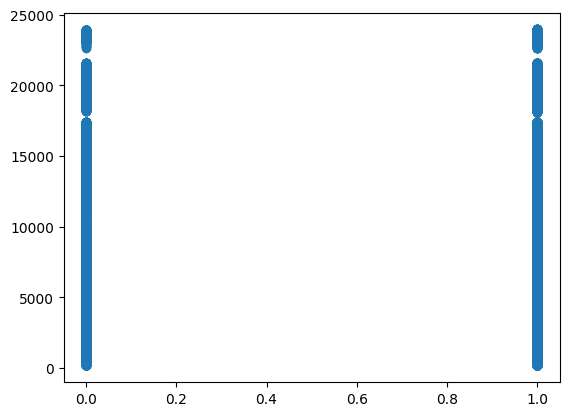

Age


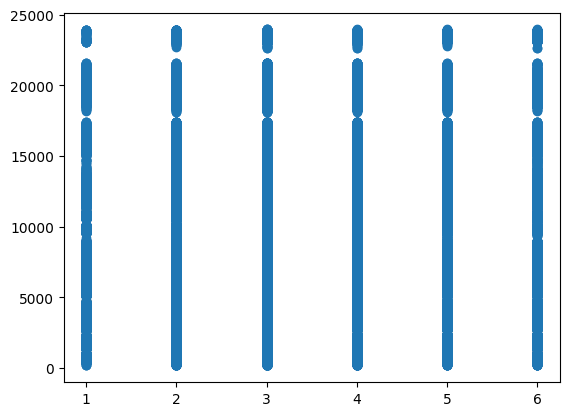

City_Category_B


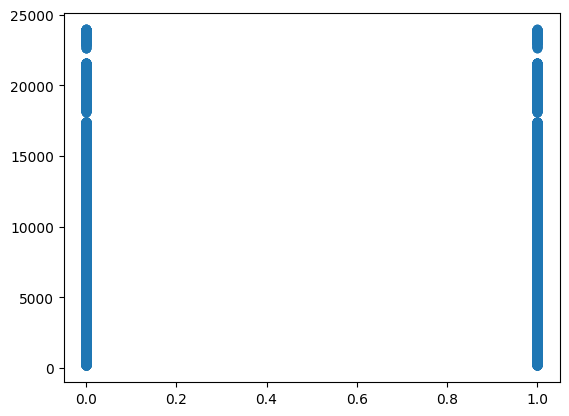

City_Category_C


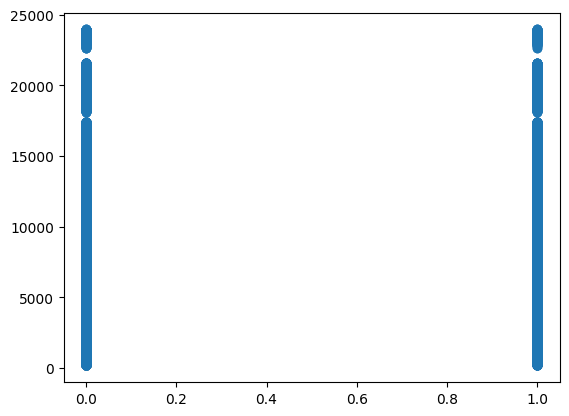

In [269]:
cs = ['Gender', 'Age', 'City_Category_B', 'City_Category_C']
for c in cs:
    print(c)
    plt.scatter(data[c], data['Purchase'])
    plt.show()

In [270]:
#your code here

In [271]:
import seaborn as sns

Нарисуйте матрицу корреляций признаков.

<Axes: >

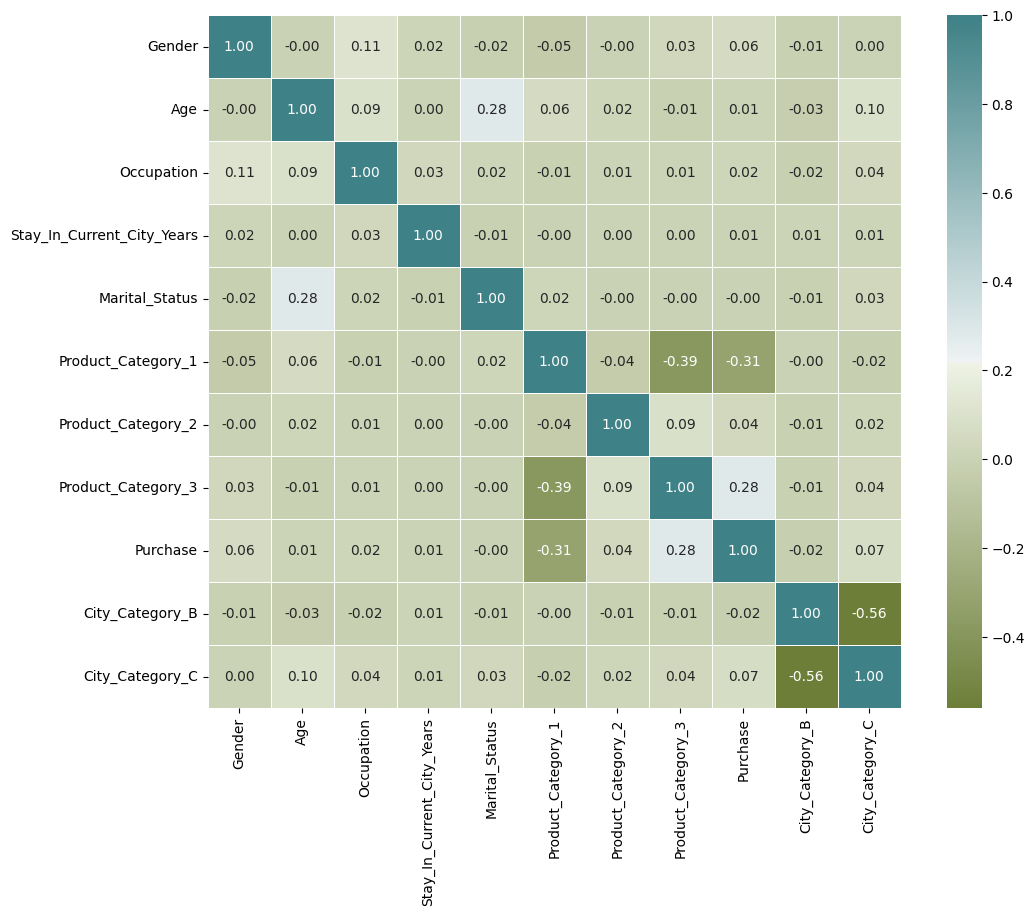

In [272]:
plt.figure(figsize=(12, 9))
corr = data.corr()

sns.heatmap(corr,annot=True,linewidths=.5,fmt= '.2f',\
            mask=np.zeros_like(corr, dtype=bool), \
            cmap=sns.diverging_palette(100,200,as_cmap=True), square=True)
#your code here

# Построение модели

Применим к нашим данным масштабирование: для того, чтобы модель лучше училась, будет неплохо привести все признаки к одному масштабу, иначе могут возникнуть проблемы с коэффициентами: если какой-то признак принимает очень большие значения, а другой - маленькие, модели будет сложно корректно подобрать веса. 

Стандартная формула для масштабирования:

$\hat{x} = \frac{x - \mu}{\sigma}$

In [273]:
X = data.drop(['Purchase'], axis=1)

y = data['Purchase']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=111)

scaler = StandardScaler().fit(Xtrain)
Xtrain = scaler.transform(Xtrain)
Xtest = scaler.transform(Xtest)

regressor = LinearRegression()
regressor.fit(Xtrain, ytrain)

ypred_train = regressor.predict(Xtrain)
ypred_test = regressor.predict(Xtest)
print(ypred_test)

[12099.21693063  4731.81919419  8468.1928964  ...  8806.88339308
 11039.8159742   8802.12091694]


In [274]:
r2_score(ytrain,ypred_train), r2_score(ytest,ypred_test)

(0.13574965133425987, 0.13535392963431603)

In [275]:
coefficients = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(regressor.coef_))], axis = 1)
coefficients

,0,0
0,Gender,214.020565
1,Age,111.196468
2,Occupation,20.532482
3,Stay_In_Current_City_Years,16.621582
4,Marital_Status,-22.104269
5,Product_Category_1,-1189.695358
6,Product_Category_2,53.056457
7,Product_Category_3,930.305634
8,City_Category_B,73.282145
9,City_Category_C,310.384221


In [276]:
#plt(regressor.coef_)

Добавим L1 регуляризацию.

In [277]:
regressor2 = Lasso(alpha=10)
regressor2.fit(Xtrain, ytrain)

ypred2 = regressor2.predict(Xtest)

print('Scores:', r2_score(ytest,ypred2), mean_squared_error(ytest,ypred2))
print(regressor2.coef_,'\n')

Scores: 0.13526335158343972 21401976.460942455
[  205.50411498    99.15193565    13.42166051     7.60304424
    -8.54699251 -1182.69862537    44.37868112   924.82152447
    51.33669333   289.75313143] 



Посмотрим, что происходит при разных значениях параметра регуляризации $\alpha$

In [278]:
for a in np.arange(0.1,100.1,25):
    regressor2 = Lasso(alpha=a)
    regressor2.fit(Xtrain, ytrain)

    ypred2 = regressor2.predict(Xtest)

    print('alpha={}'.format(a))
    print('Scores:', r2_score(ytest,ypred2), mean_squared_error(ytest,ypred2))
    print(regressor2.coef_,'\n')

alpha=0.1
Scores: 0.13535347632439831 21399745.900241602
[  213.93531486   111.07618892    20.46141684    16.53149756
   -21.9686917  -1189.62537884    52.96968104   930.25089362
    73.06063443   310.17673436] 

alpha=25.1
Scores: 0.13498132963760456 21408956.420745574
[  192.37249552    84.35131467     2.38110159     0.
    -0.         -1172.13895531    31.20453574   916.50516125
    18.07933621   258.52973058] 

alpha=50.1
Scores: 0.1344765000177326 21421450.804626573
[  168.7635833     61.33863383     0.             0.
    -0.         -1154.09424557     9.11823328   902.27648787
     0.           227.09547997] 

alpha=75.1
Scores: 0.1338997543405801 21435725.089669276
[  145.14858164    37.3617229      0.             0.
    -0.         -1135.71212715     0.           886.70905635
     0.           205.59415638] 



**Видим, что L1-регуляризация зануляет некоторые веса и таким образом производит отбор признаков.**

Подберем оптимальное значение параметра регуляризации по кросс-валидации

In [279]:
from sklearn.linear_model import LassoCV

n_alphas = 200
alphas = np.linspace(0.1, 10, n_alphas)

lasso_cv = LassoCV(alphas=alphas, 
                   cv=3, random_state=17)
lasso_cv.fit(X, y)

LassoCV(alphas=array([ 0.1       ,  0.14974874,  0.19949749,  0.24924623,  0.29899497,
        0.34874372,  0.39849246,  0.44824121,  0.49798995,  0.54773869,
        0.59748744,  0.64723618,  0.69698492,  0.74673367,  0.79648241,
        0.84623116,  0.8959799 ,  0.94572864,  0.99547739,  1.04522613,
        1.09497487,  1.14472362,  1.19447236,  1.24422111,  1.29396985,
        1.34371859,  1.39346734,  1.44321608,  1.49296482,  1.54271357,
        1.5924...
        8.30854271,  8.35829146,  8.4080402 ,  8.45778894,  8.50753769,
        8.55728643,  8.60703518,  8.65678392,  8.70653266,  8.75628141,
        8.80603015,  8.85577889,  8.90552764,  8.95527638,  9.00502513,
        9.05477387,  9.10452261,  9.15427136,  9.2040201 ,  9.25376884,
        9.30351759,  9.35326633,  9.40301508,  9.45276382,  9.50251256,
        9.55226131,  9.60201005,  9.65175879,  9.70150754,  9.75125628,
        9.80100503,  9.85075377,  9.90050251,  9.95025126, 10.        ]),
        cv=3, random_state=17)

In [280]:
lasso_cv.coef_

array([ 488.96518107,  100.78627107,    4.0147052 ,   11.65109025,
        -43.92269567, -318.71670659,    9.29888689,  148.01687317,
        154.17790032,  685.7795791 ])

In [281]:
lasso_cv.alpha_

np.float64(0.1)

Обучим модель с найденным параметром регуляризации $\alpha$

In [282]:
regressor2 = Lasso(alpha=lasso_cv.alpha_)

regressor2.fit(Xtrain, ytrain)

ypred2_train = regressor2.predict(Xtrain)
ypred2_test = regressor2.predict(Xtest)

print('Scores:', r2_score(ytrain,ypred2_train), r2_score(ytest,ypred2_test), mean_squared_error(ytrain,ypred2_train), mean_squared_error(ytest,ypred2_test))

Scores: 0.13574964670713352 0.13535347632439831 21404257.42714373 21399745.900241602


Добавим L2 регуляризацию.

In [283]:
from sklearn.linear_model import Ridge

for a in np.arange(0.0,10.1,2.5):
    regressor3 = Ridge(alpha=a)
    regressor3.fit(Xtrain, ytrain)

    ypred3 = regressor3.predict(Xtest)

    print('alpha={}'.format(a))
    print('Scores:',r2_score(ytest,ypred3), mean_squared_error(ytest,ypred3))
    print(regressor3.coef_)

alpha=0.0
Scores: 0.13535392963431603 21399734.68095512
[  214.020565     111.19646846    20.53248246    16.62158227
   -22.10426874 -1189.69535827    53.05645678   930.30563389
    73.28214478   310.38422061]
alpha=2.5
Scores: 0.13535392860197326 21399734.7065053
[  214.01959189   111.1954889     20.5327184     16.62155359
   -22.10393805 -1189.68927868    53.05673325   930.30227275
    73.28010733   310.38146481]
alpha=5.0
Scores: 0.13535392756381281 21399734.732199464
[  214.01861878   111.19450936    20.53295433    16.62152491
   -22.10360738 -1189.68319917    53.0570097    930.29891163
    73.27806994   310.37870907]
alpha=7.5
Scores: 0.1353539265198347 21399734.75803761
[  214.01764569   111.19352983    20.53319026    16.62149623
   -22.10327671 -1189.67711972    53.05728616   930.29555051
    73.27603262   310.3759534 ]
alpha=10.0
Scores: 0.13535392547003933 21399734.78401974
[  214.0166726    111.19255031    20.53342617    16.62146755
   -22.10294605 -1189.67104035    53.057562

**Ridge регрессия не зануляет веса (они могут быть очень маленькими, но ненулевыми).**

Теперь подберем оптимальное a по кросс-валидации.

In [284]:
from sklearn.linear_model import RidgeCV

n_alphas = 200
ridge_alphas = np.logspace(-2, 6, n_alphas)

ridge_cv = RidgeCV(alphas=ridge_alphas, 
                   scoring='neg_mean_squared_error',
                   cv=3)
ridge_cv.fit(X, y)

KeyboardInterrupt: 

In [195]:
ridge_cv.alpha_

np.float64(95.47716114208056)

In [197]:
regressor3 = Lasso(alpha=ridge_cv.alpha_)

regressor3.fit(Xtrain, ytrain)

ypred3_train = regressor3.predict(Xtrain)
ypred3_test = regressor3.predict(Xtest)

print('Scores:', r2_score(ytrain,ypred3_train), r2_score(ytest,ypred3_test))

Scores: 0.13390342733508676 0.13331752022508214


Добавим одновременно и L1, и L2 регуляризацию.

У ElasticNet два параметра: alpha и l1_ratio. Используйте ElasticNet со значениями параметров alpha и l1_ratio равными 0.5.

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html

In [198]:
from sklearn.linear_model import ElasticNet

In [200]:
X

,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,City_Category_B,City_Category_C
0,0,1.0,10,2,0,3,0.0,0.0,False,False
1,0,1.0,10,2,0,1,6.0,14.0,False,False
2,0,1.0,10,2,0,12,0.0,0.0,False,False
3,0,1.0,10,2,0,12,14.0,0.0,False,False
4,1,6.0,16,4,0,8,0.0,0.0,False,True
...,...,...,...,...,...,...,...,...,...,...
537572,1,4.0,16,1,0,1,2.0,0.0,False,True
537573,1,4.0,16,1,0,1,15.0,16.0,False,True
537574,1,4.0,16,1,0,8,15.0,0.0,False,True
537575,1,4.0,16,1,0,5,0.0,0.0,False,True


In [201]:
regr = ElasticNet(random_state=0)
regr.fit(X, y)
ElasticNet(random_state=0)
print(regr.coef_)
print(regr.intercept_)
print(regr.predict([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]))

[ 130.03536518   77.32381106    8.23483441   12.16236546   -6.87494744
 -309.19477713    9.81814032  150.3169855   -38.05713875  169.85081369]
9820.063546877851
[9820.06354688]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but ElasticNet was fitted with feature names
  warnings.warn(


### Посмотрим на веса, которые присвоила линейная регрессия признакам (regressor.coef_).

In [202]:
#your code here
regressor3.coef_

array([  125.94754012,    17.68450152,     0.        ,     0.        ,
           0.        , -1120.68226706,     0.        ,   873.35698664,
           0.        ,   187.95976516])

Можно записать эти веса в таблицу рядом с названиями признаков (для удобства).

In [203]:
coefficients = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(regressor3.coef_))], axis = 1)
coefficients

,0,0
0,Gender,125.947540
1,Age,17.684502
2,Occupation,0.000000
3,Stay_In_Current_City_Years,0.000000
4,Marital_Status,0.000000
5,Product_Category_1,-1120.682267
6,Product_Category_2,0.000000
7,Product_Category_3,873.356987
8,City_Category_B,0.000000
9,City_Category_C,187.959765


In [204]:
len(data),len(Xtest)

(499959, 99992)

# Задание 2

Поработайте с датасетом affairs. Предскажите значение в колонке affairs по остальным факторам.

1. Сначала проведите разведочный анализ, а именно, исследуйте зависимость таргета от каждого фактора (или пары факторов).

2. Обучите линейную регрессию, посмотрите на качество на кросс-валидации, затем разбейте данные на train и test,
обучите алгоритм на train и сделайте предсказания на train и test, выведите ошибки.

3. Посмотрите на матрицу корреляций факторов и целевой переменной. 
Если есть пары сильно коррелирующих между собой факторов, удалите один из пары.

Если есть факторы, слабо коррелирующие с таргетом, удалите их.

Заново обучите алгоритм на обновленных данных. Как изменилось его качество?

In [285]:
affairs = pd.read_csv('affairs.csv')
affairs.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


In [286]:
affairs.isnull().sum()

rate_marriage      0
age                0
yrs_married        0
children           0
religious          0
educ               0
occupation         0
occupation_husb    0
affairs            0
dtype: int64

In [287]:
import seaborn as sns

<Axes: >

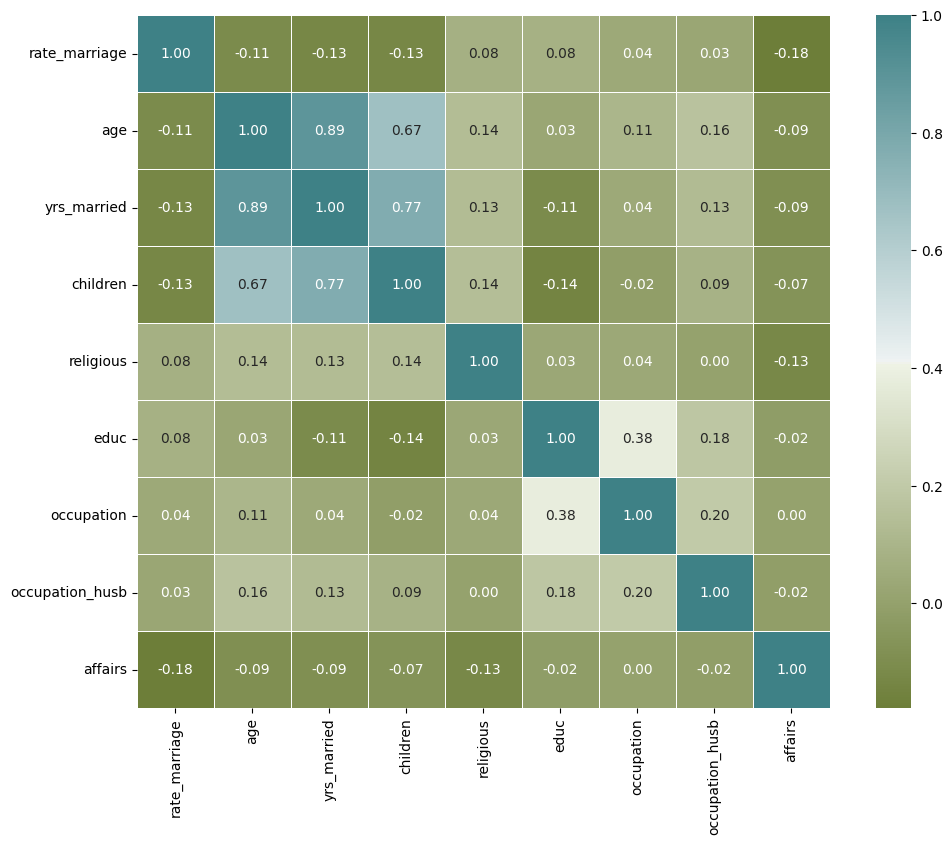

In [288]:
#1. Сначала проведите разведочный анализ, а именно, исследуйте зависимость таргета от каждого фактора (или пары факторов).
plt.figure(figsize=(12,9))

corr = affairs.corr()

sns.heatmap(corr,annot=True,linewidths=.5,fmt= '.2f',\
            mask=np.zeros_like(corr, dtype=bool), \
            cmap=sns.diverging_palette(100,200,as_cmap=True), square=True)

rate_marriage


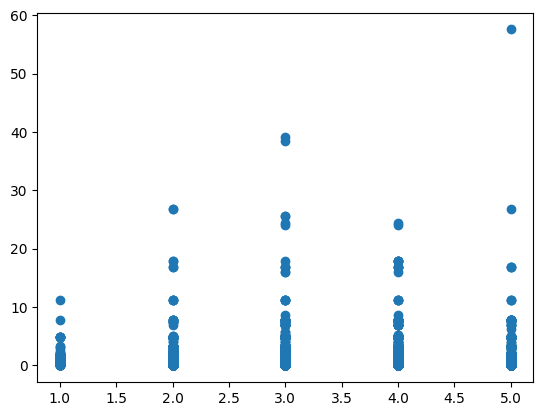

age


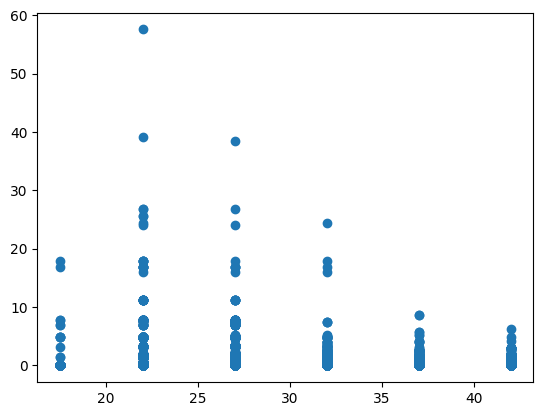

yrs_married


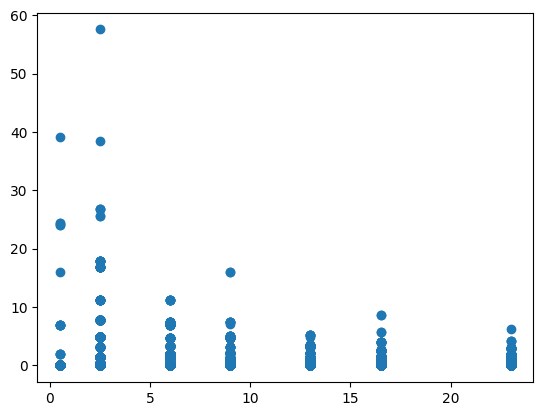

children


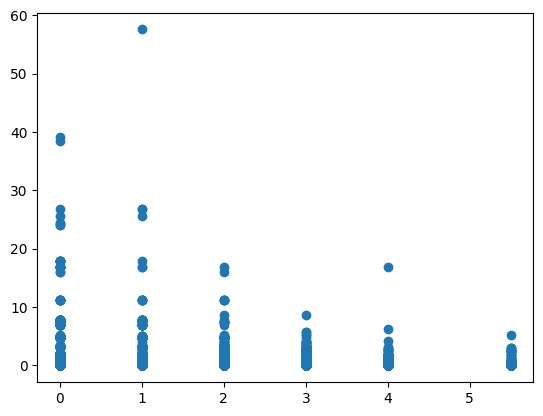

religious


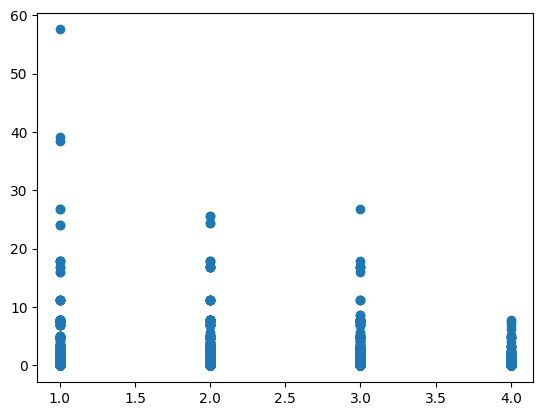

educ


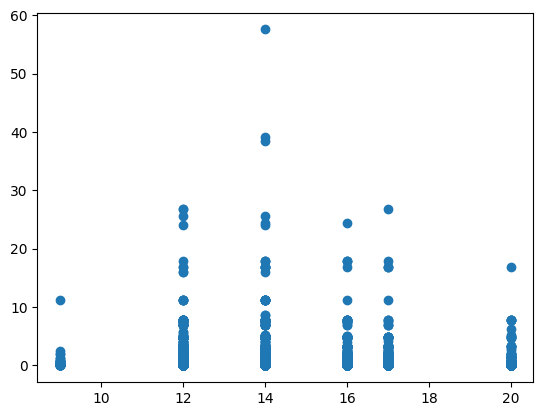

occupation


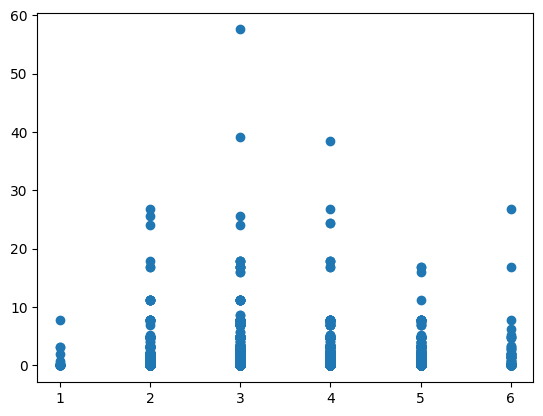

occupation_husb


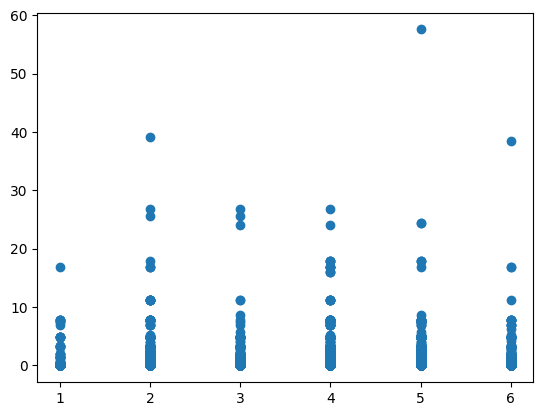

In [289]:
for c in affairs.columns:
    if c != 'affairs':
        print(c)
        plt.scatter(affairs[c], affairs['affairs'])
        plt.show()

In [294]:
#2. Обучите линейную регрессию, посмотрите на качество на кросс-валидации, затем разбейте данные на train и test,
#обучите алгоритм на train и сделайте предсказания на train и test, выведите ошибки.
X = affairs.drop(['affairs'], axis=1)

y = affairs['affairs']

Scores: 0.04617986150453335 0.05068103166935156 4.604576296523864 4.708743692160002


In [295]:
n_alphas = 200
alphas = np.linspace(0.1, 10, n_alphas)

lasso_cv = LassoCV(alphas=alphas, 
                   cv=3, random_state=17)
lasso_cv.fit(X, y)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/s

LassoCV(alphas=array([ 0.1       ,  0.14974874,  0.19949749,  0.24924623,  0.29899497,
        0.34874372,  0.39849246,  0.44824121,  0.49798995,  0.54773869,
        0.59748744,  0.64723618,  0.69698492,  0.74673367,  0.79648241,
        0.84623116,  0.8959799 ,  0.94572864,  0.99547739,  1.04522613,
        1.09497487,  1.14472362,  1.19447236,  1.24422111,  1.29396985,
        1.34371859,  1.39346734,  1.44321608,  1.49296482,  1.54271357,
        1.5924...
        8.30854271,  8.35829146,  8.4080402 ,  8.45778894,  8.50753769,
        8.55728643,  8.60703518,  8.65678392,  8.70653266,  8.75628141,
        8.80603015,  8.85577889,  8.90552764,  8.95527638,  9.00502513,
        9.05477387,  9.10452261,  9.15427136,  9.2040201 ,  9.25376884,
        9.30351759,  9.35326633,  9.40301508,  9.45276382,  9.50251256,
        9.55226131,  9.60201005,  9.65175879,  9.70150754,  9.75125628,
        9.80100503,  9.85075377,  9.90050251,  9.95025126, 10.        ]),
        cv=3, random_state=17)

In [296]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=111)

scaler = StandardScaler().fit(Xtrain)
Xtrain = scaler.transform(Xtrain)
Xtest = scaler.transform(Xtest)

regressor2 = Lasso(alpha=lasso_cv.alpha_)
regressor2.fit(Xtrain, ytrain)

ypred2_train = regressor2.predict(Xtrain)
ypred2_test = regressor2.predict(Xtest)


print('Scores:', r2_score(ytrain,ypred2_train), r2_score(ytest,ypred2_test), mean_squared_error(ytrain,ypred2_train), mean_squared_error(ytest,ypred2_test))

Scores: 0.0 -5.405256897472732e-05 4.827510041659441 4.960396209225496


In [298]:
trainMSE = mean_squared_error(ytrain,ypred2_train) ** 0.5
testMSE = mean_squared_error(ytest,ypred2_test) ** 0.5
print(trainMSE, testMSE)

2.1971595394188927 2.2271946949527104


In [300]:
#3. Посмотрите на матрицу корреляций факторов и целевой переменной. 
#Если есть пары сильно коррелирующих между собой факторов, удалите один из пары.

#Если есть факторы, слабо коррелирующие с таргетом, удалите их.

#Заново обучите алгоритм на обновленных данных. Как изменилось его качество?
affairs2 = affairs.copy()
affairs2.drop(['occupation', 'occupation_husb', 'educ'], axis=1, inplace=True)
affairs2

,rate_marriage,age,yrs_married,children,religious,affairs
0,3.0,32.0,9.0,3.0,3.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,4.666666
...,...,...,...,...,...,...
6361,5.0,32.0,13.0,2.0,3.0,0.000000
6362,4.0,32.0,13.0,1.0,1.0,0.000000
6363,5.0,22.0,2.5,0.0,2.0,0.000000
6364,5.0,32.0,6.0,1.0,3.0,0.000000


In [301]:
X2 = affairs2.drop(['affairs'], axis=1)
y2 = affairs2['affairs']
n_alphas = 200
alphas = np.linspace(0.1, 10, n_alphas)

lasso_cv = LassoCV(alphas=alphas, 
                   cv=3, random_state=17)
lasso_cv.fit(X2, y2)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/s

LassoCV(alphas=array([ 0.1       ,  0.14974874,  0.19949749,  0.24924623,  0.29899497,
        0.34874372,  0.39849246,  0.44824121,  0.49798995,  0.54773869,
        0.59748744,  0.64723618,  0.69698492,  0.74673367,  0.79648241,
        0.84623116,  0.8959799 ,  0.94572864,  0.99547739,  1.04522613,
        1.09497487,  1.14472362,  1.19447236,  1.24422111,  1.29396985,
        1.34371859,  1.39346734,  1.44321608,  1.49296482,  1.54271357,
        1.5924...
        8.30854271,  8.35829146,  8.4080402 ,  8.45778894,  8.50753769,
        8.55728643,  8.60703518,  8.65678392,  8.70653266,  8.75628141,
        8.80603015,  8.85577889,  8.90552764,  8.95527638,  9.00502513,
        9.05477387,  9.10452261,  9.15427136,  9.2040201 ,  9.25376884,
        9.30351759,  9.35326633,  9.40301508,  9.45276382,  9.50251256,
        9.55226131,  9.60201005,  9.65175879,  9.70150754,  9.75125628,
        9.80100503,  9.85075377,  9.90050251,  9.95025126, 10.        ]),
        cv=3, random_state=17)

In [302]:
Xtrain2, Xtest2, ytrain2, ytest2 = train_test_split(X2, y2, test_size=0.2, random_state=111)

scaler = StandardScaler().fit(Xtrain2)
Xtrain2 = scaler.transform(Xtrain2)
Xtest2 = scaler.transform(Xtest2)

regressor2 = Lasso(alpha=lasso_cv.alpha_)
regressor2.fit(Xtrain2, ytrain2)

ypred22_train = regressor2.predict(Xtrain2)
ypred22_test = regressor2.predict(Xtest2)


print('Scores:', r2_score(ytrain,ypred22_train), r2_score(ytest,ypred22_test), mean_squared_error(ytrain,ypred22_train), mean_squared_error(ytest,ypred22_test))

Scores: 0.0 -5.405256897472732e-05 4.827510041659441 4.960396209225496


In [305]:
coefficients = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(regressor.coef_))], axis = 1)
coefficients

,0,0
0,rate_marriage,214.020565
1,age,111.196468
2,yrs_married,20.532482
3,children,16.621582
4,religious,-22.104269
5,educ,-1189.695358
6,occupation,53.056457
7,occupation_husb,930.305634
8,NaN,73.282145
9,NaN,310.384221


# Задание 3. 

Поработайте с датасетом House Sales in King County. Обратите внимание, что не все признаки в датасете полезны. Целевая переменная - очевидно, price. 